# Fitting Spectroscopy

[`05_fitting_photometry`](05_fitting_photometry.py) left metallicity and the
dust split prior-dominated. An optical spectrum carries the absorption-line
depths — Hβ, the Mgb triplet, the Fe blends — that pin stellar age and
metallicity. This notebook fits a spectrum *alone* with the same machinery as
the quickstart (`SEDModel.build`, validated HMC) and shows what it does and
does not constrain: metallicity and age tighten sharply, but the **absolute
dust optical depth stays loose** — a spectrum sets the continuum *shape*, not
its normalisation. Adding photometry closes that gap in
[`07_joint_photo_spec`](07_joint_photo_spec.py).

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    FIXED,
    FREE,
    Fixed,
    Observation,
    SEDModel,
    Spectroscopy,
    SpectrumPrecomp,
    Uniform,
    builders,
    load_ssp_data,
    plot,
)
from tengri.inference.fitter import Fitter

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"

## Model and spectrum

An SDSS-like R≈2000 optical spectrum, 3800–9200 Å observed (rest-frame
3620–8760 Å at z = 0.05: the 4000 Å break, Hβ, Mgb, the Fe blends, Hα, and
the Ca II triplet), sampled at 260 pixels to keep the demo fast. Same FSPS
bare-stellar model as notebooks 05 and 07:
truncated-skew-normal SFH (normalisation + two timescales free; skew/trunc
fixed), free metallicity and two dust optical depths.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"
ssp_path = Path("../data") / f"{SSP_NAME}.h5"
if not ssp_path.exists():
    ssp_path = Path(tengri.download_ssp(SSP_NAME))
ssp = load_ssp_data(str(ssp_path))

Z_GAL = 0.05
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 260)  # SDSS spectral coverage
obs = Observation(spectroscopy=Spectroscopy(wave_obs=WAVE_OBS, resolution=2000))

# approx=SpectrumPrecomp() pre-rebins the SSP to the spectrum pixel centres and
# projects every forward pass through that lookup table — within ~0.03% of the
# exact wave-grid spectrum but ~30x faster per evaluation, so a converged HMC
# fit takes seconds rather than minutes. It is the spectroscopic analogue of
# WavePrecomp; valid for low-to-medium resolution (R ≲ a few thousand), where
# the continuum is smooth across a pixel.
sed_model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    approx=SpectrumPrecomp(),
    sfh=builders.sfh.tsnorm(defaults=FIXED, log_total_mass=FREE, peak_lbt_gyr=FREE, width_gyr=FREE),
    dust=builders.dust.two_component(
        defaults=FIXED, law_bc="calzetti",
        tau_bc=Uniform(0.0, 1.0), tau_diff=Uniform(0.0, 1.0),
    ),
    neb=builders.neb.none(),
    stellar={"met_logzsol": Uniform(-1.5, 0.3)},
    redshift=Fixed(Z_GAL),
)
print(f"Free parameters ({sed_model.spec.n_free}): {', '.join(sed_model.spec.free_params)}")

Free parameters (6): dust_tau_bc, dust_tau_diff, met_logzsol, sfh_tsnorm_log_total_mass, sfh_tsnorm_peak_lbt_gyr, sfh_tsnorm_width_gyr


/Users/suchethacooray/.claude-squad/worktrees/cs/olpish-docs_18b4cf0410b66420/src/tengri/parameters/groups.py:568: UserWarning: Parameter 'sfh_tsnorm_skew' was marked FIXED via the '*': FIXED wildcard but its registry default carries no explicit ``default=``. Falling back to the prior midpoint (Array(0., dtype=float64, weak_type=True)); the contract test ``tests/contract/test_param_defaults.py`` should be failing in CI to flag this. Fix: set ``default=<physical_value>`` at the declaration site (e.g. ``Uniform(0, 5, default=2.0)``).
  final_dist, tag = _resolve_value(
/Users/suchethacooray/.claude-squad/worktrees/cs/olpish-docs_18b4cf0410b66420/src/tengri/parameters/groups.py:568: UserWarning: Parameter 'sfh_tsnorm_trunc' was marked FIXED via the '*': FIXED wildcard but its registry default carries no explicit ``default=``. Falling back to the prior midpoint (Array(5.5, dtype=float64, weak_type=True)); the contract test ``tests/contract/test_param_defaults.py`` should be failing in CI t

## Mock spectrum

Truth with an interior metallicity; one noisy realisation at SNR = 30 per
pixel.

In [3]:
truth = sed_model.spec.sample(jax.random.PRNGKey(0))
truth = {
    **truth,
    "met_logzsol": jnp.array(-0.30),
    "dust_tau_bc": jnp.array(0.30),
    "dust_tau_diff": jnp.array(0.25),
    "sfh_tsnorm_log_total_mass": jnp.array(10.5),
}
truth_full = {**sed_model.spec.get_fixed_values(), **{k: float(v) for k, v in truth.items()}}

p_spec = np.asarray(sed_model.predict_spectrum(truth_full, wave_obs=WAVE_OBS))
noise = p_spec / 30.0
flux = p_spec + np.random.default_rng(0).normal(size=p_spec.shape) * noise
wave_um = np.asarray(WAVE_OBS) / 1e4
print(f"Truth metallicity log(Z/Zsun) = {float(truth['met_logzsol']):+.2f}")
print(f"Mock: {len(flux)}-pixel R=2000 spectrum, SNR = 30/pixel")

Truth metallicity log(Z/Zsun) = -0.30
Mock: 260-pixel R=2000 spectrum, SNR = 30/pixel


## Fit

The convergence-validated fixed-length HMC recipe (dense mass, n_warmup=1000,
n_leapfrog=20) mixes this six-parameter posterior cleanly. With
`SpectrumPrecomp` the forward pass is the lookup-table path, so the whole fit
runs in seconds rather than minutes.

In [4]:
t0 = time.perf_counter()
fitter = Fitter(sed_model, flux, noise, data_type="spectroscopy")
posterior = fitter.run("mcmc_hmc", n_warmup=1000, n_samples=600, n_leapfrog_steps=20,
                       dense_mass_matrix=True, target_accept_rate=0.9, key=jax.random.PRNGKey(1))
rhat = posterior.rhat()
print(f"HMC: {time.perf_counter() - t0:.0f}s   "
      f"max R-hat {max(float(v) for v in rhat.values()):.3f}   "
      f"divergences {posterior.diagnostics.get('n_divergent', 'n/a')}")

/tmp/claude-501/ipykernel_70127/3614968734.py:2: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  fitter = Fitter(sed_model, flux, noise, data_type="spectroscopy")


  MAP initialization (200 steps)...


  MAP init done (loss=281.41)


HMC: 19s   max R-hat 1.005   divergences 0


## Recovery — what a spectrum alone pins

Metallicity, stellar mass, and the SFH timescales recover tightly. The
diffuse dust optical depth is constrained (it shapes the continuum slope) but
the birth-cloud component `tau_bc` stays broad — a spectrum fixes the
continuum shape, not the overall dust normalisation.

In [5]:
params = sed_model.spec.free_params
print(f"{'parameter':<28}{'truth':>9}{'p16':>9}{'p50':>9}{'p84':>9}  cover")
print("-" * 66)
n_cov = 0
for p in params:
    s = np.asarray(posterior.samples[p])
    lo, med, hi = np.percentile(s, [16, 50, 84])
    tv = float(truth_full[p])
    ok = lo <= tv <= hi
    n_cov += ok
    print(f"{p:<28}{tv:>9.3f}{lo:>9.3f}{med:>9.3f}{hi:>9.3f}  {'ok' if ok else 'miss'}")
print(f"\n68% coverage: {n_cov}/{len(params)}")

parameter                       truth      p16      p50      p84  cover
------------------------------------------------------------------
dust_tau_bc                     0.300    0.272    0.510    0.719  ok
dust_tau_diff                   0.250    0.199    0.235    0.275  ok
met_logzsol                    -0.300   -0.327   -0.256   -0.201  ok
sfh_tsnorm_log_total_mass      10.500   10.490   10.501   10.514  ok
sfh_tsnorm_peak_lbt_gyr         2.024    1.877    2.043    2.250  ok
sfh_tsnorm_width_gyr            0.483    0.429    0.505    0.602  ok

68% coverage: 6/6


## Posterior spectrum fit + residuals

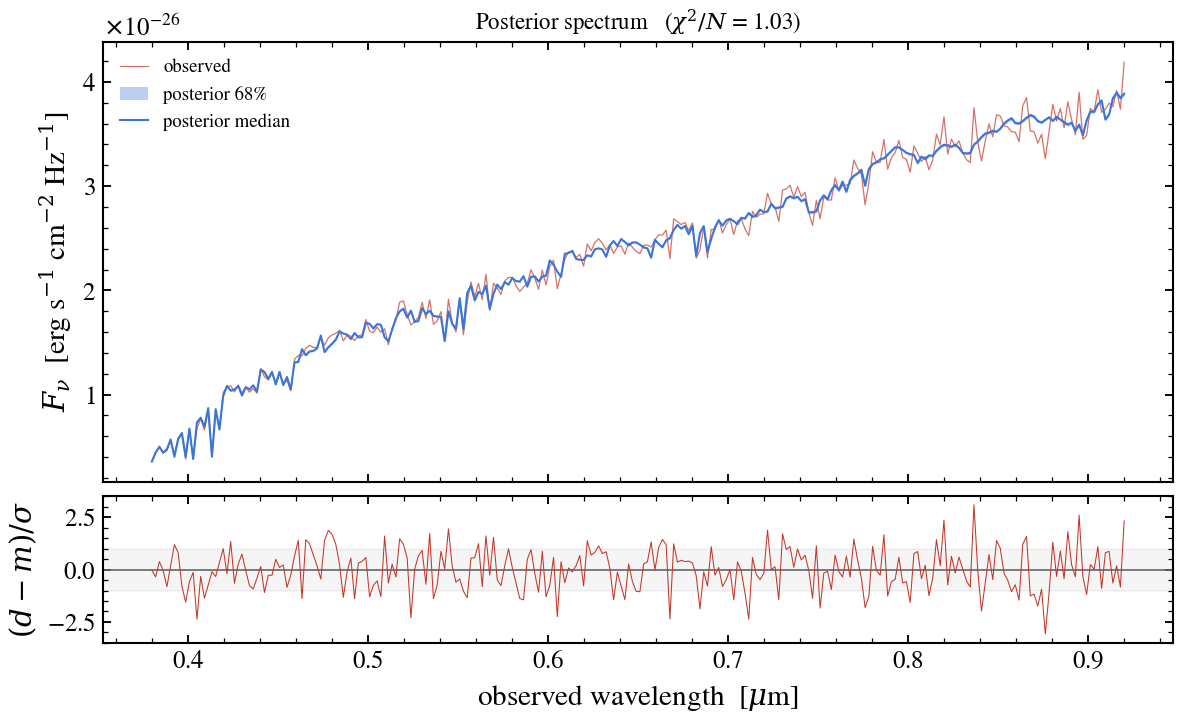

In [6]:
N_DRAW = 60
idx = np.linspace(0, len(next(iter(posterior.samples.values()))) - 1, N_DRAW).astype(int)
fixed = sed_model.spec.get_fixed_values()
draws = [{**fixed, **{k: float(v[i]) for k, v in posterior.samples.items()}} for i in idx]
spec_draws = np.stack([np.asarray(sed_model.predict_spectrum(p, wave_obs=WAVE_OBS)) for p in draws])
sp_lo, sp_med, sp_hi = np.percentile(spec_draws, [16, 50, 84], axis=0)
resid = (flux - sp_med) / noise
chi2_dof = float(np.sum(resid**2) / len(resid))

fig = plt.figure(figsize=(9.2, 5.2))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax, ax_r = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
ax.plot(wave_um, flux, color=C_DATA, lw=0.6, alpha=0.7, label="observed")
ax.fill_between(wave_um, sp_lo, sp_hi, color=C_POST, alpha=0.35, lw=0, label="posterior 68%")
ax.plot(wave_um, sp_med, color=C_POST, lw=1.0, label="posterior median")
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.set_title(rf"Posterior spectrum   ($\chi^2/N$ = {chi2_dof:.2f})", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.setp(ax.get_xticklabels(), visible=False)
ax_r.axhspan(-1, 1, alpha=0.08, color="0.5")
ax_r.axhline(0, color="0.4", lw=0.8)
ax_r.plot(wave_um, resid, color=C_DATA, lw=0.5)
ax_r.set_ylim(-3.5, 3.5)
ax_r.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_r.set_ylabel(r"$(d-m)/\sigma$")
fig.savefig(FIG_DIR / "06_spectrum_fit.png", dpi=300, bbox_inches="tight")
plt.show()

## Corner

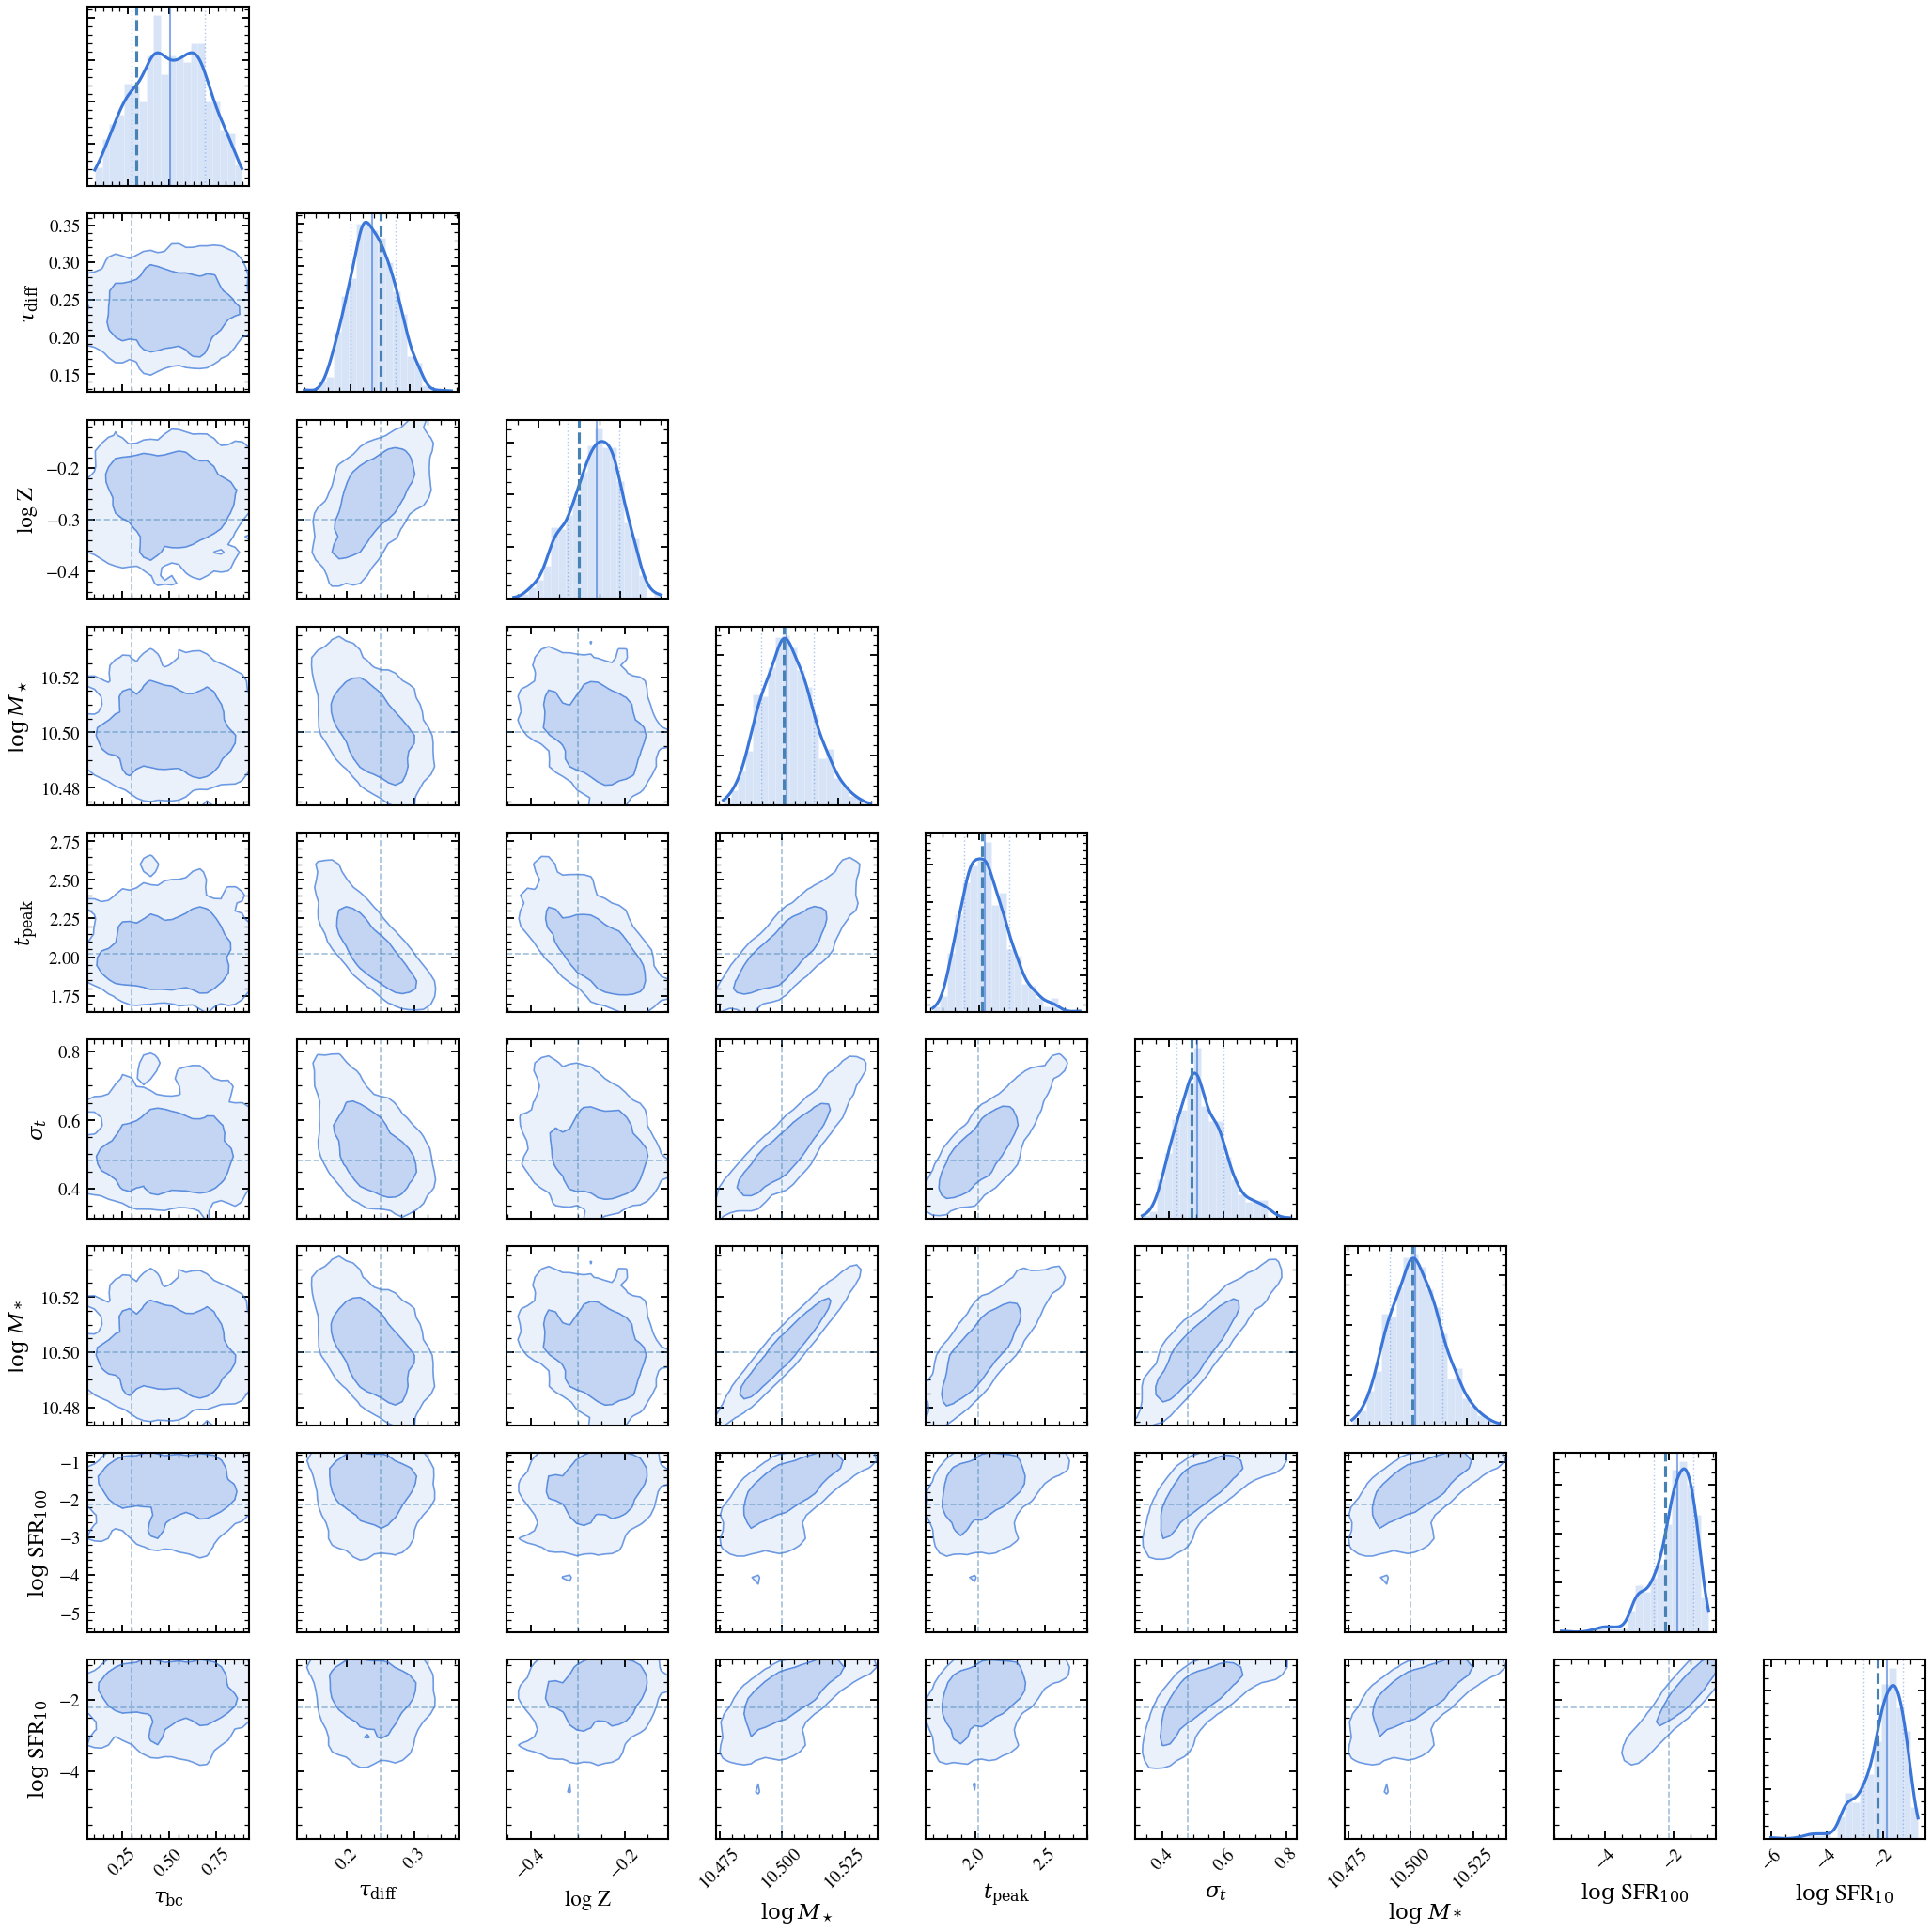

In [7]:
labels = {
    "met_logzsol": r"$\log Z/Z_\odot$",
    "dust_tau_bc": r"$\tau_{\rm bc}$",
    "dust_tau_diff": r"$\tau_{\rm diff}$",
    "sfh_tsnorm_log_total_mass": r"$\log M_\star$",
    "sfh_tsnorm_peak_lbt_gyr": r"$t_{\rm peak}$",
    "sfh_tsnorm_width_gyr": r"$\sigma_t$",
}
fig_corner = posterior.plot_corner(truths=truth_full, color=C_POST)
for ax_c in fig_corner.axes:  # readable axis labels in place of parameter keys
    if ax_c.get_xlabel() in labels:
        ax_c.set_xlabel(labels[ax_c.get_xlabel()], fontsize=11)
    if ax_c.get_ylabel() in labels:
        ax_c.set_ylabel(labels[ax_c.get_ylabel()], fontsize=11)
fig_corner.savefig(FIG_DIR / "06_corner.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary

A converged spectroscopy-only fit (R̂ < 1.05) pins stellar age, metallicity,
and mass from the absorption features, but leaves the dust normalisation
loose. [`07_joint_photo_spec`](07_joint_photo_spec.py) adds broadband
photometry, which fixes the dust normalisation and tightens the rest.